In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
infl_ukr = pd.read_csv('C:\\Users\\User\\Desktop\\дані для диплому\\infl_ukr.csv')
infl_ukr

,Показник,Базисний період,Територіальний розріз,Тип товарів і послуг,Періодичність,Одиниця виміру,Масштабування,Кількість десяткових знаків,Спеціальне значення даних,Примітки часового ряду,...,2025-M05,2025-M06,2025-M07,2025-M08,2025-M09,2025-M10,2025-M11,2025-M12,2026-M01,2026-M02
0,SSSU:DF_PRICE_CHANGE_CONSUMER_GOODS_SERVICE(27...,INDEX_CONSUMPRICE.PREV_MONTH.UA000000000000000...,Україна,Індекс споживчих цін,Місячна,Відсоток,Одиниці,Один,NaN,1. З 1991 року. 2. Індекси споживчих цін до ві...,...,101.3,100.8,99.8,99.8,100.3,100.9,100.4,100.2,100.7,101


In [3]:
infl_ukr = infl_ukr.iloc[:, -420:]
infl_ukr

,1991-M03,1991-M04,1991-M05,1991-M06,1991-M07,1991-M08,1991-M09,1991-M10,1991-M11,1991-M12,...,2025-M05,2025-M06,2025-M07,2025-M08,2025-M09,2025-M10,2025-M11,2025-M12,2026-M01,2026-M02
0,NaN,NaN,NaN,NaN,NaN,104,104.5,105.9,116.5,124.6,...,101.3,100.8,99.8,99.8,100.3,100.9,100.4,100.2,100.7,101


In [4]:
infl_ukr = infl_ukr.T
infl_ukr = infl_ukr.reset_index()
infl_ukr.columns = ['Показник', 'infl_ukr']

In [5]:
infl_ukr['Показник'] = infl_ukr['Показник'].str.replace('-M', '-', regex=False)
infl_ukr['Показник'] = pd.to_datetime(infl_ukr['Показник'])
infl_ukr = infl_ukr.set_index('Показник')

In [6]:
infl_ukr = infl_ukr.dropna()
infl_ukr

,infl_ukr
Показник,
1991-08-01,104.0
1991-09-01,104.5
1991-10-01,105.9
1991-11-01,116.5
1991-12-01,124.6
...,...
2025-10-01,100.9
2025-11-01,100.4
2025-12-01,100.2


In [7]:
infl_ukr.index = infl_ukr.index + pd.offsets.MonthEnd(0)

In [8]:
infl_ukr

,infl_ukr
Показник,
1991-08-31,104.0
1991-09-30,104.5
1991-10-31,105.9
1991-11-30,116.5
1991-12-31,124.6
...,...
2025-10-31,100.9
2025-11-30,100.4
2025-12-31,100.2


In [9]:
infl_ukr['infl_ukr'] = infl_ukr['infl_ukr'].astype(float)
infl_ukr['infl_ukr_log'] = np.log(infl_ukr['infl_ukr'])

In [10]:
infl_ukr['infl_ukr_log'] = infl_ukr['infl_ukr_log'].diff().dropna()

In [11]:
infl_ukr.tail()

,infl_ukr,infl_ukr_log
Показник,,
2025-10-31,100.9,0.005964
2025-11-30,100.4,-0.004968
2025-12-31,100.2,-0.001994
2026-01-31,100.7,0.004978
2026-02-28,101.0,0.002975


In [12]:
Ukraine_GDP_q = pd.read_csv('C:\\Users\\User\\Desktop\\дані для диплому національні\\ВВП_квартальне.csv')
Ukraine_GDP_q

,Показник,Територіальний розріз,Вид ціни,Періодичність,Одиниця виміру,Масштабування,Кількість десяткових знаків,Конфіденційність,Примітки часового ряду,Примітки спостереження,...,2023-Q1,2023-Q2,2023-Q3,2023-Q4,2024-Q1,2024-Q2,2024-Q3,2024-Q4,2025-Q1,2025-Q2
0,Валовий внутрішній продукт,Україна,У фактичних цінах,Квартальна,Гривня,Мільйони,Нуль,NaN,1. Дані наведено без урахування тимчасово окуп...,1. Дані попередні./Рreliminary data.,...,1388161.0,1483162.0,1807595.0,1949043.0,1629400.0,1742535.0,2092353.0,2194371.0,1923124.0,2021451.0


In [13]:
Ukraine_GDP_q = Ukraine_GDP_q.drop(['Примітки спостереження', 'Вид ціни', 'Примітки часового ряду', 'Конфіденційність', 'Кількість десяткових знаків', 'Масштабування', 'Одиниця виміру', 'Періодичність', 'Територіальний розріз', 'Примітки часового ряду'], axis=1)

In [14]:
Ukraine_GDP_q = Ukraine_GDP_q.T
Ukraine_GDP_q = Ukraine_GDP_q.reset_index()
Ukraine_GDP_q.columns = ['Показник', 'ВВП України']
Ukraine_GDP_q = Ukraine_GDP_q.drop(0)

In [15]:
df_Ukraine_GDP_q = Ukraine_GDP_q.copy()
df_Ukraine_GDP_q['Показник'] = df_Ukraine_GDP_q['Показник'].str.replace('-Q', 'Q')
df_Ukraine_GDP_q['Показник'] = pd.to_datetime(df_Ukraine_GDP_q['Показник'])
df_Ukraine_GDP_q.set_index('Показник', inplace=True)

C:\Users\User\AppData\Local\Temp\ipykernel_25136\801829612.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_Ukraine_GDP_q['Показник'] = pd.to_datetime(df_Ukraine_GDP_q['Показник'])


In [16]:
df_Ukraine_GDP_q.head()

,ВВП України
Показник,
2015-01-01,375991.0
2015-04-01,456715.0
2015-07-01,566997.0
2015-10-01,588841.0
2016-01-01,455298.0


In [17]:
df_Ukraine_GDP_q.index = df_Ukraine_GDP_q.index + pd.offsets.MonthEnd(3)
df_Ukraine_GDP_q.head()

,ВВП України
Показник,
2015-03-31,375991.0
2015-06-30,456715.0
2015-09-30,566997.0
2015-12-31,588841.0
2016-03-31,455298.0


In [18]:
df_Ukraine_GDP_q['gdp_ua'] = df_Ukraine_GDP_q['ВВП України'].astype(float)
df_Ukraine_GDP_q['gdp_ua_log'] = np.log(df_Ukraine_GDP_q['gdp_ua'])

In [19]:
df_Ukraine_GDP_q['gdp_ua_log'] = df_Ukraine_GDP_q['gdp_ua_log'].diff().dropna()

In [20]:
df_Ukraine_GDP_q.head()

,ВВП України,gdp_ua,gdp_ua_log
Показник,,,
2015-03-31,375991.0,375991.0,NaN
2015-06-30,456715.0,456715.0,0.194494
2015-09-30,566997.0,566997.0,0.216294
2015-12-31,588841.0,588841.0,0.037802
2016-03-31,455298.0,455298.0,-0.257204


In [21]:
main_data = pd.merge(infl_ukr['infl_ukr_log'], df_Ukraine_GDP_q['gdp_ua_log'], on='Показник', how='left')
main_data

,infl_ukr_log,gdp_ua_log
Показник,,
1991-08-31,NaN,NaN
1991-09-30,0.004796,NaN
1991-10-31,0.013308,NaN
1991-11-30,0.095396,NaN
1991-12-31,0.067217,NaN
...,...,...
2025-10-31,0.005964,NaN
2025-11-30,-0.004968,NaN
2025-12-31,-0.001994,NaN


In [22]:
export_q = pd.read_csv('C:\\Users\\User\\Desktop\\дані для диплому\\export.csv')
export_q

,Показник,Одиниця виміру,Масштабування,Кількість десяткових знаків,Спеціальне значення даних,Примітки часового ряду,Примітки спостереження,2015-Q1,2015-Q2,2015-Q3,...,2023-Q3,2023-Q4,2024-Q1,2024-Q2,2024-Q3,2024-Q4,2025-Q1,2025-Q2,2025-Q3,2025-Q4
0,SSSU:DF_QUARTERLY_NATIONAL_ACCOUNTS(14.0.0),EXPORTS_GOODS.UA00000000000000000.CURR_PRICES....,Мільйони,Нуль,NaN,Дані наведено без урахування тимчасово окупова...,Дані попередні.,249852,250632,266601,...,419478,481164,547562,556476,555756,613786,549603,556021,540931,616032


In [23]:
export_q = export_q.drop(['Примітки спостереження', 'Спеціальне значення даних', 'Примітки часового ряду', 'Кількість десяткових знаків', 'Масштабування', 'Одиниця виміру', 'Примітки часового ряду', 'Показник'], axis=1)

In [24]:
export_q = export_q.T
export_q = export_q.reset_index()
export_q.columns = ['Показник', 'export']
export_q = export_q.drop(0)

In [25]:
export_q = export_q.copy()
export_q['Показник'] = export_q['Показник'].str.replace('-Q', 'Q')
export_q['Показник'] = pd.to_datetime(export_q['Показник'])
export_q.set_index('Показник', inplace=True)

C:\Users\User\AppData\Local\Temp\ipykernel_25136\1286718322.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  export_q['Показник'] = pd.to_datetime(export_q['Показник'])


In [26]:
export_q.head()

,export
Показник,
2015-04-01,250632
2015-07-01,266601
2015-10-01,278843
2016-01-01,252255
2016-04-01,283545


In [27]:
export_q.index = export_q.index + pd.offsets.MonthEnd(3)
export_q.head()

,export
Показник,
2015-06-30,250632
2015-09-30,266601
2015-12-31,278843
2016-03-31,252255
2016-06-30,283545


In [28]:
export_q['export'] = export_q['export'].astype(float)
export_q['export_log'] = np.log(export_q['export'])

In [29]:
export_q['export_log'] = export_q['export_log'].diff().dropna()

In [30]:
main_data = pd.merge(main_data, export_q['export_log'], on='Показник', how='left')
main_data

,infl_ukr_log,gdp_ua_log,export_log
Показник,,,
1991-08-31,NaN,NaN,NaN
1991-09-30,0.004796,NaN,NaN
1991-10-31,0.013308,NaN,NaN
1991-11-30,0.095396,NaN,NaN
1991-12-31,0.067217,NaN,NaN
...,...,...,...
2025-10-31,0.005964,NaN,NaN
2025-11-30,-0.004968,NaN,NaN
2025-12-31,-0.001994,NaN,0.130007


In [31]:
import_q = pd.read_csv('C:\\Users\\User\\Desktop\\дані для диплому\\import.csv')
import_q

,Показник,Територіальний розріз,Вид ціни,Періодичність,Одиниця виміру,Масштабування,Кількість десяткових знаків,Спеціальне значення даних,Примітки часового ряду,Примітки спостереження,...,2023-Q3,2023-Q4,2024-Q1,2024-Q2,2024-Q3,2024-Q4,2025-Q1,2025-Q2,2025-Q3,2025-Q4
0,SSSU:DF_QUARTERLY_NATIONAL_ACCOUNTS(14.0.0),IMPORTS_GOODS.UA00000000000000000.CURR_PRICES....,У фактичних цінах,Квартальна,Гривня,Мільйони,Нуль,NaN,Дані наведено без урахування тимчасово окупова...,Дані попередні.,...,806630,845914,830886,931939,992589,1077036,1025075,1103501,1169841,1332116


In [32]:
import_q = import_q.drop(['Примітки спостереження', 'Вид ціни', 'Примітки часового ряду', 'Кількість десяткових знаків', 'Масштабування', 'Одиниця виміру', 'Періодичність', 'Територіальний розріз', 'Примітки часового ряду', 'Спеціальне значення даних'], axis=1)

In [33]:
import_q = import_q.T
import_q = import_q.reset_index()
import_q.columns = ['Показник', 'import']
import_q = import_q.drop(0)

In [34]:
import_q.head()

,Показник,import
1,2015-Q1,263833
2,2015-Q2,255842
3,2015-Q3,279179
4,2015-Q4,299000
5,2016-Q1,297742


In [35]:
import_q['Показник'] = import_q['Показник'].str.replace('-Q', 'Q')
import_q['Показник'] = pd.to_datetime(import_q['Показник'])
import_q.set_index('Показник', inplace=True)

C:\Users\User\AppData\Local\Temp\ipykernel_25136\1592946767.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  import_q['Показник'] = pd.to_datetime(import_q['Показник'])


In [36]:
import_q.index = import_q.index + pd.offsets.MonthEnd(3)
import_q.head()

,import
Показник,
2015-03-31,263833
2015-06-30,255842
2015-09-30,279179
2015-12-31,299000
2016-03-31,297742


In [37]:
import_q['import'] = import_q['import'].astype(float)
import_q['import_log'] = np.log(import_q['import'])
import_q['import_log'] = import_q['import_log'].diff().dropna()

In [38]:
main_data = pd.merge(main_data, import_q['import_log'], on='Показник', how='left')
main_data

,infl_ukr_log,gdp_ua_log,export_log,import_log
Показник,,,,
1991-08-31,NaN,NaN,NaN,NaN
1991-09-30,0.004796,NaN,NaN,NaN
1991-10-31,0.013308,NaN,NaN,NaN
1991-11-30,0.095396,NaN,NaN,NaN
1991-12-31,0.067217,NaN,NaN,NaN
...,...,...,...,...
2025-10-31,0.005964,NaN,NaN,NaN
2025-11-30,-0.004968,NaN,NaN,NaN
2025-12-31,-0.001994,NaN,0.130007,0.129901


In [39]:
empl_ua = pd.read_csv('C:\\Users\\User\\Desktop\\mfvar_data\\empl_ua.csv')
empl_ua

,Показник,Територіальний розріз,Вікова група,Одиниця виміру,Періодичність,Масштабування,Кількість десяткових знаків,Спеціальне значення даних,Примітки набору даних,Примітки часового ряду,...,2019-Q3,2019-Q4,2020-Q1,2020-Q2,2020-Q3,2020-Q4,2021-Q1,2021-Q2,2021-Q3,2021-Q4
0,Рівень зайнятості населення (кумулятивно),Україна,Працездатний вік,Відсоток,Квартальна,Одиниці,Один,NaN,NaN,1. Відсотків до всього населення. 2. Дані за 2...,...,67.8,67.6,67.9,66.1,65.9,65.6,64.6,65.2,65.6,65.3


In [40]:
empl_ua = empl_ua.drop(['Примітки спостереження', 'Примітки часового ряду', 'Кількість десяткових знаків', 'Масштабування', 'Одиниця виміру', 'Періодичність', 'Територіальний розріз', 'Примітки часового ряду', 'Спеціальне значення даних', 'Вікова група', 'Примітки набору даних'], axis=1)

In [41]:
empl_ua = empl_ua.T
empl_ua = empl_ua.reset_index()
empl_ua.columns = ['Показник', 'empl_ua']
empl_ua = empl_ua.drop(0)

In [42]:
empl_ua.head()

,Показник,empl_ua
1,2015-Q1,64.2
2,2015-Q2,64.6
3,2015-Q3,65
4,2015-Q4,64.7
5,2016-Q1,63.4


In [43]:
empl_ua['Показник'] = empl_ua['Показник'].str.replace('-Q', 'Q')
empl_ua['Показник'] = pd.to_datetime(empl_ua['Показник'])
empl_ua.set_index('Показник', inplace=True)

C:\Users\User\AppData\Local\Temp\ipykernel_25136\864375622.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  empl_ua['Показник'] = pd.to_datetime(empl_ua['Показник'])


In [44]:
empl_ua.index = empl_ua.index + pd.offsets.MonthEnd(3)
empl_ua.head()

,empl_ua
Показник,
2015-03-31,64.2
2015-06-30,64.6
2015-09-30,65
2015-12-31,64.7
2016-03-31,63.4


In [45]:
empl_ua['empl_ua'] = empl_ua['empl_ua'].astype(float)
empl_ua['empl_ua_log'] = np.log(empl_ua['empl_ua'])
empl_ua['empl_ua_log'] = empl_ua['empl_ua_log'].diff().dropna()

In [46]:
main_data = pd.merge(main_data, empl_ua['empl_ua_log'], on='Показник', how='left')
main_data

,infl_ukr_log,gdp_ua_log,export_log,import_log,empl_ua_log
Показник,,,,,
1991-08-31,NaN,NaN,NaN,NaN,NaN
1991-09-30,0.004796,NaN,NaN,NaN,NaN
1991-10-31,0.013308,NaN,NaN,NaN,NaN
1991-11-30,0.095396,NaN,NaN,NaN,NaN
1991-12-31,0.067217,NaN,NaN,NaN,NaN
...,...,...,...,...,...
2025-10-31,0.005964,NaN,NaN,NaN,NaN
2025-11-30,-0.004968,NaN,NaN,NaN,NaN
2025-12-31,-0.001994,NaN,0.130007,0.129901,NaN


In [47]:
empl_kyiv = pd.read_csv('C:\\Users\\User\\Desktop\\mfvar_data\\empl_kyiv.csv')
empl_kyiv

,Показник,Територіальний розріз,Вікова група,Одиниця виміру,Періодичність,Масштабування,Кількість десяткових знаків,Спеціальне значення даних,Примітки набору даних,Примітки часового ряду,...,2019-Q3,2019-Q4,2020-Q1,2020-Q2,2020-Q3,2020-Q4,2021-Q1,2021-Q2,2021-Q3,2021-Q4
0,Рівень зайнятості населення (кумулятивно),Київська,Працездатний вік,Відсоток,Квартальна,Одиниці,Один,NaN,NaN,Відсотків до всього населення.,...,70.1,69.9,70.1,68.7,68.6,68.2,66.3,67,67.7,67.3


In [48]:
empl_kyiv = empl_kyiv.drop(['Примітки спостереження', 'Примітки часового ряду', 'Кількість десяткових знаків', 'Масштабування', 'Одиниця виміру', 'Періодичність', 'Територіальний розріз', 'Примітки часового ряду', 'Спеціальне значення даних', 'Вікова група', 'Примітки набору даних'], axis=1)

In [49]:
empl_kyiv = empl_kyiv.T
empl_kyiv = empl_kyiv.reset_index()
empl_kyiv.columns = ['Показник', 'empl_kyiv']
empl_kyiv = empl_kyiv.drop(0)

In [50]:
empl_kyiv['Показник'] = empl_kyiv['Показник'].str.replace('-Q', 'Q')
empl_kyiv['Показник'] = pd.to_datetime(empl_kyiv['Показник'])
empl_kyiv.set_index('Показник', inplace=True)

C:\Users\User\AppData\Local\Temp\ipykernel_25136\885295781.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  empl_kyiv['Показник'] = pd.to_datetime(empl_kyiv['Показник'])


In [51]:
empl_kyiv.index = empl_kyiv.index + pd.offsets.MonthEnd(3)
empl_kyiv.head()

,empl_kyiv
Показник,
2015-03-31,67.3
2015-06-30,67.3
2015-09-30,67.7
2015-12-31,67.7
2016-03-31,67.5


In [52]:
empl_kyiv['empl_kyiv'] = empl_kyiv['empl_kyiv'].astype(float)
empl_kyiv['empl_kyiv_log'] = np.log(empl_kyiv['empl_kyiv'])
empl_kyiv['empl_kyiv_log'] = empl_kyiv['empl_kyiv_log'].diff().dropna()

In [53]:
main_data = pd.merge(main_data, empl_kyiv['empl_kyiv_log'], on='Показник', how='left')
main_data

,infl_ukr_log,gdp_ua_log,export_log,import_log,empl_ua_log,empl_kyiv_log
Показник,,,,,,
1991-08-31,NaN,NaN,NaN,NaN,NaN,NaN
1991-09-30,0.004796,NaN,NaN,NaN,NaN,NaN
1991-10-31,0.013308,NaN,NaN,NaN,NaN,NaN
1991-11-30,0.095396,NaN,NaN,NaN,NaN,NaN
1991-12-31,0.067217,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...
2025-10-31,0.005964,NaN,NaN,NaN,NaN,NaN
2025-11-30,-0.004968,NaN,NaN,NaN,NaN,NaN
2025-12-31,-0.001994,NaN,0.130007,0.129901,NaN,NaN


In [54]:
constr_ind = pd.read_csv('C:\\Users\\User\\Desktop\\mfvar_data\\construction_ind.csv')
constr_ind

,Показник,Базисний період,Територіальний розріз,Інші розрізи,Періодичність,Одиниця виміру,Масштабування,Кількість десяткових знаків,Спеціальне значення даних,Примітки набору даних,...,2025-M05,2025-M06,2025-M07,2025-M08,2025-M09,2025-M10,2025-M11,2025-M12,2026-M01,2026-M02
0,Індекс цін у будівництві,До попереднього місяця,Україна,Усього,Місячна,Відсоток,Одиниці,Один,NaN,NaN,...,100.3,100.4,100.8,100.3,100.1,100.2,100.7,100.6,101.1,101.8


In [55]:
constr_ind = constr_ind.drop(['Примітки спостереження', 'Базисний період', 'Інші розрізи', 'Примітки часового ряду', 'Кількість десяткових знаків', 'Масштабування', 'Одиниця виміру', 'Періодичність', 'Територіальний розріз', 'Примітки часового ряду', 'Спеціальне значення даних', 'Примітки набору даних'], axis=1)

In [56]:
constr_ind = constr_ind.T
constr_ind = constr_ind.reset_index()
constr_ind.columns = ['Показник', 'constr_ind']
constr_ind = constr_ind.drop(0)

In [57]:
constr_ind['Показник'] = constr_ind['Показник'].str.replace('-M', '-', regex=False)
constr_ind['Показник'] = pd.to_datetime(constr_ind['Показник'])
constr_ind = constr_ind.set_index('Показник')

In [58]:
constr_ind.index = constr_ind.index + pd.offsets.MonthEnd(0)
constr_ind.head()

,constr_ind
Показник,
2003-01-31,99.8
2003-02-28,99.7
2003-03-31,100.5
2003-04-30,100.5
2003-05-31,100.4


In [59]:
constr_ind['constr_ind'] = constr_ind['constr_ind'].astype(float)
constr_ind['constr_ind_log'] = np.log(constr_ind['constr_ind'])
constr_ind['constr_ind_log'] = constr_ind['constr_ind_log'].diff().dropna()

In [60]:
main_data = pd.merge(main_data, constr_ind['constr_ind_log'], on='Показник', how='left')
main_data

,infl_ukr_log,gdp_ua_log,export_log,import_log,empl_ua_log,empl_kyiv_log,constr_ind_log
Показник,,,,,,,
1991-08-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1991-09-30,0.004796,NaN,NaN,NaN,NaN,NaN,NaN
1991-10-31,0.013308,NaN,NaN,NaN,NaN,NaN,NaN
1991-11-30,0.095396,NaN,NaN,NaN,NaN,NaN,NaN
1991-12-31,0.067217,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...
2025-10-31,0.005964,NaN,NaN,NaN,NaN,NaN,0.000999
2025-11-30,-0.004968,NaN,NaN,NaN,NaN,NaN,0.004978
2025-12-31,-0.001994,NaN,0.130007,0.129901,NaN,NaN,-0.000994


In [61]:
house_ind = pd.read_csv('C:\\Users\\User\\Desktop\\mfvar_data\\house_ind.csv')
house_ind

,Показник,Базисний період,Територіальний розріз,Інші розрізи,Періодичність,Одиниця виміру,Масштабування,Кількість десяткових знаків,Спеціальне значення даних,Примітки набору даних,...,2023-Q3,2023-Q4,2024-Q1,2024-Q2,2024-Q3,2024-Q4,2025-Q1,2025-Q2,2025-Q3,2025-Q4
0,Індекс цін на житло,До попереднього кварталу,Україна,Квартири двокімнатні на первинному ринку,Квартальна,Відсоток,Одиниці,Один,NaN,NaN,...,104.9,102.1,105.3,102.2,103.9,104,104.2,103.6,100,104.2


In [62]:
house_ind = house_ind.drop(['Примітки спостереження', 'Базисний період', 'Інші розрізи', 'Примітки часового ряду', 'Кількість десяткових знаків', 'Масштабування', 'Одиниця виміру', 'Періодичність', 'Територіальний розріз', 'Примітки часового ряду', 'Спеціальне значення даних', 'Примітки набору даних'], axis=1)

In [63]:
house_ind = house_ind.T
house_ind = house_ind.reset_index()
house_ind.columns = ['Показник', 'house_ind']
house_ind = house_ind.drop(0)

In [64]:
house_ind['Показник'] = house_ind['Показник'].str.replace('-Q', 'Q')
house_ind['Показник'] = pd.to_datetime(house_ind['Показник'])
house_ind.set_index('Показник', inplace=True)

C:\Users\User\AppData\Local\Temp\ipykernel_25136\989592762.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  house_ind['Показник'] = pd.to_datetime(house_ind['Показник'])


In [65]:
house_ind.index = house_ind.index + pd.offsets.MonthEnd(3)
house_ind.head()

,house_ind
Показник,
2016-03-31,100.9
2016-06-30,98
2016-09-30,101.1
2016-12-31,105.2
2017-03-31,101


In [66]:
house_ind['house_ind'] = house_ind['house_ind'].astype(float)
house_ind['house_ind_log'] = np.log(house_ind['house_ind'])
house_ind['house_ind_log'] = house_ind['house_ind_log'].diff().dropna()

In [67]:
main_data = pd.merge(main_data, house_ind['house_ind_log'], on='Показник', how='left')
main_data

,infl_ukr_log,gdp_ua_log,export_log,import_log,empl_ua_log,empl_kyiv_log,constr_ind_log,house_ind_log
Показник,,,,,,,,
1991-08-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1991-09-30,0.004796,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1991-10-31,0.013308,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1991-11-30,0.095396,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1991-12-31,0.067217,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...
2025-10-31,0.005964,NaN,NaN,NaN,NaN,NaN,0.000999,NaN
2025-11-30,-0.004968,NaN,NaN,NaN,NaN,NaN,0.004978,NaN
2025-12-31,-0.001994,NaN,0.130007,0.129901,NaN,NaN,-0.000994,0.041142


In [68]:
house_space_kyiv = pd.read_csv('C:\\Users\\User\\Desktop\\mfvar_data\\house_space_kyiv.csv')
house_space_kyiv

,Показник,Територіальний розріз,Тип будівлі,Періодичність,Одиниця виміру,Масштабування,Кількість десяткових знаків,Спеціальне значення даних,Примітки набору даних,Примітки часового ряду,...,2023-Q3,2023-Q4,2024-Q1,2024-Q2,2024-Q3,2024-Q4,2025-Q1,2025-Q2,2025-Q3,2025-Q4
0,"Житлова площа квартир у житлових будинках, при...",Київська,Житлові будинки без житлових будинків для коле...,Квартальна,Квадратний метр,Одиниці,Нуль,Конфіденційна статистична інформація,З 01.01.2024 року назви щодо типів будівель на...,1. З урахуванням прийнятих в експлуатацію житл...,...,NaN,591626,195466,406140,NaN,NaN,192225,376701,580574,NaN


In [69]:
house_space_kyiv = house_space_kyiv.drop(['Примітки спостереження', 'Тип будівлі', 'Примітки часового ряду', 'Кількість десяткових знаків', 'Масштабування', 'Одиниця виміру', 'Періодичність', 'Територіальний розріз', 'Примітки часового ряду', 'Спеціальне значення даних', 'Примітки набору даних'], axis=1)

In [70]:
house_space_kyiv = house_space_kyiv.T
house_space_kyiv = house_space_kyiv.reset_index()
house_space_kyiv.columns = ['Показник', 'house_space_kyiv']
house_space_kyiv = house_space_kyiv.drop(0)

In [71]:
house_space_kyiv['Показник'] = house_space_kyiv['Показник'].str.replace('-Q', 'Q')
house_space_kyiv['Показник'] = pd.to_datetime(house_space_kyiv['Показник'])
house_space_kyiv.set_index('Показник', inplace=True)

C:\Users\User\AppData\Local\Temp\ipykernel_25136\218067807.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  house_space_kyiv['Показник'] = pd.to_datetime(house_space_kyiv['Показник'])


In [72]:
house_space_kyiv.index = house_space_kyiv.index + pd.offsets.MonthEnd(3)
house_space_kyiv.head()

,house_space_kyiv
Показник,
2018-03-31,133498
2018-06-30,268435
2018-09-30,440507
2018-12-31,700348
2019-03-31,174605


In [73]:
house_space_kyiv['house_space_kyiv'] = house_space_kyiv['house_space_kyiv'].astype(float)
house_space_kyiv['house_space_kyiv_log'] = np.log(house_space_kyiv['house_space_kyiv'])
house_space_kyiv['house_space_kyiv_log'] = house_space_kyiv['house_space_kyiv_log'].diff().dropna()

In [74]:
main_data = pd.merge(main_data, house_space_kyiv['house_space_kyiv_log'], on='Показник', how='left')
main_data

,infl_ukr_log,gdp_ua_log,export_log,import_log,empl_ua_log,empl_kyiv_log,constr_ind_log,house_ind_log,house_space_kyiv_log
Показник,,,,,,,,,
1991-08-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1991-09-30,0.004796,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1991-10-31,0.013308,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1991-11-30,0.095396,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1991-12-31,0.067217,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...
2025-10-31,0.005964,NaN,NaN,NaN,NaN,NaN,0.000999,NaN,NaN
2025-11-30,-0.004968,NaN,NaN,NaN,NaN,NaN,0.004978,NaN,NaN
2025-12-31,-0.001994,NaN,0.130007,0.129901,NaN,NaN,-0.000994,0.041142,NaN


In [75]:
house_space_ua = pd.read_csv('C:\\Users\\User\\Desktop\\mfvar_data\\house_space_ua.csv')
house_space_ua

,Показник,Територіальний розріз,Тип будівлі,Періодичність,Одиниця виміру,Масштабування,Кількість десяткових знаків,Спеціальне значення даних,Примітки набору даних,Примітки часового ряду,...,2023-Q3,2023-Q4,2024-Q1,2024-Q2,2024-Q3,2024-Q4,2025-Q1,2025-Q2,2025-Q3,2025-Q4
0,"Житлова площа квартир у житлових будинках, при...",Україна,Житлові будинки без житлових будинків для коле...,Квартальна,Квадратний метр,Одиниці,Нуль,Конфіденційна статистична інформація,З 01.01.2024 року назви щодо типів будівель на...,1. Дані наведено без урахування тимчасово окуп...,...,NaN,3389532,NaN,NaN,3111724,4518426,1036502,1937425,2944300,4295907


In [76]:
house_space_ua = house_space_ua.drop(['Примітки спостереження', 'Тип будівлі', 'Примітки часового ряду', 'Кількість десяткових знаків', 'Масштабування', 'Одиниця виміру', 'Періодичність', 'Територіальний розріз', 'Примітки часового ряду', 'Спеціальне значення даних', 'Примітки набору даних'], axis=1)

In [77]:
house_space_ua = house_space_ua.T
house_space_ua = house_space_ua.reset_index()
house_space_ua.columns = ['Показник', 'house_space_ua']
house_space_ua = house_space_ua.drop(0)

In [78]:
house_space_ua['Показник'] = house_space_ua['Показник'].str.replace('-Q', 'Q')
house_space_ua['Показник'] = pd.to_datetime(house_space_ua['Показник'])
house_space_ua.set_index('Показник', inplace=True)

C:\Users\User\AppData\Local\Temp\ipykernel_25136\4223594852.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  house_space_ua['Показник'] = pd.to_datetime(house_space_ua['Показник'])


In [79]:
house_space_ua.index = house_space_ua.index + pd.offsets.MonthEnd(3)
house_space_ua.head()

,house_space_ua
Показник,
2018-03-31,876116
2018-06-30,1523985
2018-09-30,2436786
2018-12-31,4062604
2019-03-31,1135242


In [80]:
house_space_ua['house_space_ua'] = house_space_ua['house_space_ua'].astype(float)
house_space_ua['house_space_ua_log'] = np.log(house_space_ua['house_space_ua'])
house_space_ua['house_space_ua_log'] = house_space_ua['house_space_ua_log'].diff().dropna()

In [81]:
main_data = pd.merge(main_data, house_space_ua['house_space_ua_log'], on='Показник', how='left')
main_data

,infl_ukr_log,gdp_ua_log,export_log,import_log,empl_ua_log,empl_kyiv_log,constr_ind_log,house_ind_log,house_space_kyiv_log,house_space_ua_log
Показник,,,,,,,,,,
1991-08-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1991-09-30,0.004796,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1991-10-31,0.013308,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1991-11-30,0.095396,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1991-12-31,0.067217,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
2025-10-31,0.005964,NaN,NaN,NaN,NaN,NaN,0.000999,NaN,NaN,NaN
2025-11-30,-0.004968,NaN,NaN,NaN,NaN,NaN,0.004978,NaN,NaN,NaN
2025-12-31,-0.001994,NaN,0.130007,0.129901,NaN,NaN,-0.000994,0.041142,NaN,0.377792


In [82]:
main_data = main_data.loc['2010-01-01':'2025-12-31']

In [83]:
main_data

,infl_ukr_log,gdp_ua_log,export_log,import_log,empl_ua_log,empl_kyiv_log,constr_ind_log,house_ind_log,house_space_kyiv_log,house_space_ua_log
Показник,,,,,,,,,,
2010-01-31,0.008880,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN
2010-02-28,0.000982,NaN,NaN,NaN,NaN,NaN,0.009872,NaN,NaN,NaN
2010-03-31,-0.009862,NaN,NaN,NaN,NaN,NaN,-0.005911,NaN,NaN,NaN
2010-04-30,-0.011964,NaN,NaN,NaN,NaN,NaN,0.001974,NaN,NaN,NaN
2010-05-31,-0.003014,NaN,NaN,NaN,NaN,NaN,0.004919,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
2025-08-31,0.000000,NaN,NaN,NaN,NaN,NaN,-0.004973,NaN,NaN,NaN
2025-09-30,0.004998,NaN,-0.027514,0.058380,NaN,NaN,-0.001996,-0.035367,0.432566,0.418511
2025-10-31,0.005964,NaN,NaN,NaN,NaN,NaN,0.000999,NaN,NaN,NaN


In [105]:
conf_ind_finance = pd.read_csv('C:\\Users\\User\\Desktop\\mfvar_data\\conf_ind_finance.csv')
conf_ind_finance

,Тенденції ділової активності,Показник,Територіальний розріз,Тренд,Вид економічної діяльності,Періодичність,Одиниця виміру,Масштабування,Кількість десяткових знаків,Спеціальне значення даних,...,2022-Q3,2022-Q4,2023-Q1,2023-Q2,2023-Q3,2023-Q4,2024-Q1,2024-Q2,2024-Q3,2024-Q4
0,Індикатори ділових очікувань,Індикатор ділової впевненості у сфері фінансов...,Україна,Індикатор,Фінансова та страхова діяльність,Квартальна,Відсоток,Одиниці,Один,NaN,...,-57,-28.7,-16.7,-8,-3.3,6.3,-3.3,-4.7,-5.3,-4


In [106]:
conf_ind_finance = conf_ind_finance.drop(['Примітки спостереження', 'Тенденції ділової активності', 'Тренд', 'Вид економічної діяльності', 'Примітки часового ряду', 'Кількість десяткових знаків', 'Масштабування', 'Одиниця виміру', 'Періодичність', 'Територіальний розріз', 'Примітки часового ряду', 'Спеціальне значення даних', 'Примітки набору даних'], axis=1)

In [107]:
conf_ind_finance = conf_ind_finance.T
conf_ind_finance = conf_ind_finance.reset_index()
conf_ind_finance.columns = ['Показник', 'conf_ind_finance']
conf_ind_finance = conf_ind_finance.drop(0)

In [108]:
conf_ind_finance['Показник'] = conf_ind_finance['Показник'].str.replace('-Q', 'Q')
conf_ind_finance['Показник'] = pd.to_datetime(conf_ind_finance['Показник'])
conf_ind_finance.set_index('Показник', inplace=True)

C:\Users\User\AppData\Local\Temp\ipykernel_25136\849067857.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  conf_ind_finance['Показник'] = pd.to_datetime(conf_ind_finance['Показник'])


In [109]:
conf_ind_finance.index = conf_ind_finance.index + pd.offsets.MonthEnd(3)
conf_ind_finance.head()

,conf_ind_finance
Показник,
2015-03-31,-45
2015-06-30,-35.3
2015-09-30,-32.7
2015-12-31,-27
2016-03-31,-24.7


In [111]:
conf_ind_finance['conf_ind_finance'] = conf_ind_finance['conf_ind_finance'].astype(float)
shift = abs(conf_ind_finance['conf_ind_finance'].min()) + 1
conf_ind_finance['conf_ind_finance_log'] = np.log(conf_ind_finance['conf_ind_finance'] + shift)

In [112]:
conf_ind_finance['conf_ind_finance_log'] = conf_ind_finance['conf_ind_finance_log'].diff().dropna()

In [114]:
main_data = pd.merge(main_data, conf_ind_finance['conf_ind_finance_log'], on='Показник', how='left')
main_data

,infl_ukr_log,gdp_ua_log,export_log,import_log,empl_ua_log,empl_kyiv_log,constr_ind_log,house_ind_log,house_space_kyiv_log,house_space_ua_log,conf_ind_finance_log
Показник,,,,,,,,,,,
2010-01-31,0.008880,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN
2010-02-28,0.000982,NaN,NaN,NaN,NaN,NaN,0.009872,NaN,NaN,NaN,NaN
2010-03-31,-0.009862,NaN,NaN,NaN,NaN,NaN,-0.005911,NaN,NaN,NaN,NaN
2010-04-30,-0.011964,NaN,NaN,NaN,NaN,NaN,0.001974,NaN,NaN,NaN,NaN
2010-05-31,-0.003014,NaN,NaN,NaN,NaN,NaN,0.004919,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
2025-08-31,0.000000,NaN,NaN,NaN,NaN,NaN,-0.004973,NaN,NaN,NaN,NaN
2025-09-30,0.004998,NaN,-0.027514,0.058380,NaN,NaN,-0.001996,-0.035367,0.432566,0.418511,NaN
2025-10-31,0.005964,NaN,NaN,NaN,NaN,NaN,0.000999,NaN,NaN,NaN,NaN


In [115]:
conf_ind_build = pd.read_csv('C:\\Users\\User\\Desktop\\mfvar_data\\conf_ind_build.csv')
conf_ind_build

,Тенденції ділової активності,Показник,Територіальний розріз,Тренд,Вид економічної діяльності,Періодичність,Одиниця виміру,Масштабування,Кількість десяткових знаків,Спеціальне значення даних,...,2024-Q1,2024-Q2,2024-Q3,2024-Q4,2025-Q1,2025-Q2,2025-Q3,2025-Q4,2026-Q1,2026-Q2
0,Індикатори ділових очікувань,Індикатор ділової впевненості в будівництві,Україна,Індикатор,Будівництво,Квартальна,Відсоток,Одиниці,Один,NaN,...,-40.6,-41.2,-46.3,-40.9,-38.7,-35,-32,-28.9,-27.6,-25.7


In [116]:
conf_ind_build = conf_ind_build.drop(['Примітки спостереження', 'Тенденції ділової активності', 'Тренд', 'Вид економічної діяльності', 'Примітки часового ряду', 'Кількість десяткових знаків', 'Масштабування', 'Одиниця виміру', 'Періодичність', 'Територіальний розріз', 'Примітки часового ряду', 'Спеціальне значення даних', 'Примітки набору даних'], axis=1)

In [117]:
conf_ind_build = conf_ind_build.T
conf_ind_build = conf_ind_build.reset_index()
conf_ind_build.columns = ['Показник', 'conf_ind_build']
conf_ind_build = conf_ind_build.drop(0)

In [118]:
conf_ind_build['Показник'] = conf_ind_build['Показник'].str.replace('-Q', 'Q')
conf_ind_build['Показник'] = pd.to_datetime(conf_ind_build['Показник'])
conf_ind_build.set_index('Показник', inplace=True)

C:\Users\User\AppData\Local\Temp\ipykernel_25136\2963974463.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  conf_ind_build['Показник'] = pd.to_datetime(conf_ind_build['Показник'])


In [119]:
conf_ind_build.index = conf_ind_build.index + pd.offsets.MonthEnd(3)
conf_ind_build.head()

,conf_ind_build
Показник,
2015-03-31,-44
2015-06-30,-46.7
2015-09-30,-44.6
2015-12-31,-38.1
2016-03-31,-34.7


In [120]:
conf_ind_build['conf_ind_build'] = conf_ind_build['conf_ind_build'].astype(float)
shift = abs(conf_ind_build['conf_ind_build'].min()) + 1
conf_ind_build['conf_ind_build_log'] = np.log(conf_ind_build['conf_ind_build'] + shift)

In [121]:
conf_ind_build['conf_ind_build_log'] = conf_ind_build['conf_ind_build_log'].diff().dropna()

In [122]:
main_data = pd.merge(main_data, conf_ind_build['conf_ind_build_log'], on='Показник', how='left')
main_data

,infl_ukr_log,gdp_ua_log,export_log,import_log,empl_ua_log,empl_kyiv_log,constr_ind_log,house_ind_log,house_space_kyiv_log,house_space_ua_log,conf_ind_finance_log,conf_ind_build_log
Показник,,,,,,,,,,,,
2010-01-31,0.008880,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN
2010-02-28,0.000982,NaN,NaN,NaN,NaN,NaN,0.009872,NaN,NaN,NaN,NaN,NaN
2010-03-31,-0.009862,NaN,NaN,NaN,NaN,NaN,-0.005911,NaN,NaN,NaN,NaN,NaN
2010-04-30,-0.011964,NaN,NaN,NaN,NaN,NaN,0.001974,NaN,NaN,NaN,NaN,NaN
2010-05-31,-0.003014,NaN,NaN,NaN,NaN,NaN,0.004919,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
2025-08-31,0.000000,NaN,NaN,NaN,NaN,NaN,-0.004973,NaN,NaN,NaN,NaN,NaN
2025-09-30,0.004998,NaN,-0.027514,0.058380,NaN,NaN,-0.001996,-0.035367,0.432566,0.418511,NaN,0.082013
2025-10-31,0.005964,NaN,NaN,NaN,NaN,NaN,0.000999,NaN,NaN,NaN,NaN,NaN


In [123]:
conf_ind_service = pd.read_csv('C:\\Users\\User\\Desktop\\mfvar_data\\conf_ind_service.csv')
conf_ind_service

,Тенденції ділової активності,Показник,Територіальний розріз,Тренд,Вид економічної діяльності,Періодичність,Одиниця виміру,Масштабування,Кількість десяткових знаків,Спеціальне значення даних,...,2024-Q1,2024-Q2,2024-Q3,2024-Q4,2025-Q1,2025-Q2,2025-Q3,2025-Q4,2026-Q1,2026-Q2
0,Індикатори ділових очікувань,Індикатор ділової впевненості у сфері послуг,Україна,Індикатор,Сфера послуг,Квартальна,Відсоток,Одиниці,Один,NaN,...,-8,-6.5,-8.8,-7.7,-6.1,-6.7,-4.2,-5,-4.5,-7.5


In [124]:
conf_ind_service = conf_ind_service.drop(['Примітки спостереження', 'Тенденції ділової активності', 'Тренд', 'Вид економічної діяльності', 'Примітки часового ряду', 'Кількість десяткових знаків', 'Масштабування', 'Одиниця виміру', 'Періодичність', 'Територіальний розріз', 'Примітки часового ряду', 'Спеціальне значення даних', 'Примітки набору даних'], axis=1)

In [125]:
conf_ind_service = conf_ind_service.T
conf_ind_service = conf_ind_service.reset_index()
conf_ind_service.columns = ['Показник', 'conf_ind_service']
conf_ind_service = conf_ind_service.drop(0)

In [126]:
conf_ind_service['Показник'] = conf_ind_service['Показник'].str.replace('-Q', 'Q')
conf_ind_service['Показник'] = pd.to_datetime(conf_ind_service['Показник'])
conf_ind_service.set_index('Показник', inplace=True)

C:\Users\User\AppData\Local\Temp\ipykernel_25136\4191179953.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  conf_ind_service['Показник'] = pd.to_datetime(conf_ind_service['Показник'])


In [127]:
conf_ind_service.index =conf_ind_service.index + pd.offsets.MonthEnd(3)
conf_ind_service.head()

,conf_ind_service
Показник,
2015-03-31,-33.2
2015-06-30,-29.3
2015-09-30,-25.6
2015-12-31,-19.4
2016-03-31,-18


In [128]:
conf_ind_service['conf_ind_service'] = conf_ind_service['conf_ind_service'].astype(float)
shift = abs(conf_ind_service['conf_ind_service'].min()) + 1
conf_ind_service['conf_ind_service_log'] = np.log(conf_ind_service['conf_ind_service'] + shift)

In [129]:
conf_ind_service['conf_ind_service_log'] = conf_ind_service['conf_ind_service_log'].diff().dropna()

In [130]:
main_data = pd.merge(main_data, conf_ind_service['conf_ind_service_log'], on='Показник', how='left')
main_data

,infl_ukr_log,gdp_ua_log,export_log,import_log,empl_ua_log,empl_kyiv_log,constr_ind_log,house_ind_log,house_space_kyiv_log,house_space_ua_log,conf_ind_finance_log,conf_ind_build_log,conf_ind_service_log
Показник,,,,,,,,,,,,,
2010-01-31,0.008880,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN
2010-02-28,0.000982,NaN,NaN,NaN,NaN,NaN,0.009872,NaN,NaN,NaN,NaN,NaN,NaN
2010-03-31,-0.009862,NaN,NaN,NaN,NaN,NaN,-0.005911,NaN,NaN,NaN,NaN,NaN,NaN
2010-04-30,-0.011964,NaN,NaN,NaN,NaN,NaN,0.001974,NaN,NaN,NaN,NaN,NaN,NaN
2010-05-31,-0.003014,NaN,NaN,NaN,NaN,NaN,0.004919,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-08-31,0.000000,NaN,NaN,NaN,NaN,NaN,-0.004973,NaN,NaN,NaN,NaN,NaN,NaN
2025-09-30,0.004998,NaN,-0.027514,0.058380,NaN,NaN,-0.001996,-0.035367,0.432566,0.418511,NaN,0.082013,0.049663
2025-10-31,0.005964,NaN,NaN,NaN,NaN,NaN,0.000999,NaN,NaN,NaN,NaN,NaN,NaN


In [131]:
kyiv_gdp = pd.read_csv('C:\\Users\\User\\Desktop\\mfvar_data\\kyiv_gdp.csv')
kyiv_gdp

,Показник,Територіальний розріз,Періодичність,Одиниця виміру,Масштабування,Кількість десяткових знаків,Спеціальне значення даних,Примітки набору даних,Примітки часового ряду,Примітки спостереження,...,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021
0,Валовий регіональний продукт,Київська,Річна,Гривня,Мільйони,Нуль,NaN,NaN,NaN,NaN,...,69663,68931,79561,104030,128638,156829,198142,218647,242406,291519


In [133]:
kyiv_gdp = kyiv_gdp.drop(['Примітки спостереження', 'Примітки часового ряду', 'Кількість десяткових знаків', 'Масштабування', 'Одиниця виміру', 'Періодичність', 'Територіальний розріз', 'Примітки часового ряду', 'Спеціальне значення даних', 'Примітки набору даних'], axis=1)

In [135]:
kyiv_gdp = kyiv_gdp.T
kyiv_gdp = kyiv_gdp.reset_index()
kyiv_gdp.columns = ['Показник', 'kyiv_gdp']
kyiv_gdp = kyiv_gdp.drop(0)

In [136]:
kyiv_gdp['Показник'] = kyiv_gdp['Показник'].str.replace('-Q', 'Q')
kyiv_gdp['Показник'] = pd.to_datetime(kyiv_gdp['Показник'])
kyiv_gdp.set_index('Показник', inplace=True)

In [138]:
kyiv_gdp.index = kyiv_gdp.index + pd.offsets.MonthEnd(12)
kyiv_gdp.head()

,kyiv_gdp
Показник,
2004-12-31,11883
2005-12-31,15362
2006-12-31,19188
2007-12-31,26221
2008-12-31,35687


In [139]:
kyiv_gdp['kyiv_gdp'] = kyiv_gdp['kyiv_gdp'].astype(float)
kyiv_gdp['kyiv_gdp_log'] = np.log(kyiv_gdp['kyiv_gdp'])
kyiv_gdp['kyiv_gdp_log'] = kyiv_gdp['kyiv_gdp_log'].diff().dropna()

In [140]:
main_data = pd.merge(main_data, kyiv_gdp['kyiv_gdp_log'], on='Показник', how='left')
main_data

,infl_ukr_log,gdp_ua_log,export_log,import_log,empl_ua_log,empl_kyiv_log,constr_ind_log,house_ind_log,house_space_kyiv_log,house_space_ua_log,conf_ind_finance_log,conf_ind_build_log,conf_ind_service_log,kyiv_gdp_log
Показник,,,,,,,,,,,,,,
2010-01-31,0.008880,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-02-28,0.000982,NaN,NaN,NaN,NaN,NaN,0.009872,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-03-31,-0.009862,NaN,NaN,NaN,NaN,NaN,-0.005911,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-04-30,-0.011964,NaN,NaN,NaN,NaN,NaN,0.001974,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-05-31,-0.003014,NaN,NaN,NaN,NaN,NaN,0.004919,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-08-31,0.000000,NaN,NaN,NaN,NaN,NaN,-0.004973,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-09-30,0.004998,NaN,-0.027514,0.058380,NaN,NaN,-0.001996,-0.035367,0.432566,0.418511,NaN,0.082013,0.049663,NaN
2025-10-31,0.005964,NaN,NaN,NaN,NaN,NaN,0.000999,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [141]:
path = r'C:\Users\User\Desktop\дані для диплому\mfvar1_dataset.csv'
main_data.to_csv(path, index=True, encoding='utf-8')

In [142]:
main_data.sample()

,infl_ukr_log,gdp_ua_log,export_log,import_log,empl_ua_log,empl_kyiv_log,constr_ind_log,house_ind_log,house_space_kyiv_log,house_space_ua_log,conf_ind_finance_log,conf_ind_build_log,conf_ind_service_log,kyiv_gdp_log
Показник,,,,,,,,,,,,,,
2024-12-31,-0.004919,0.047606,0.099317,0.081651,NaN,NaN,-0.003976,0.000962,NaN,0.372987,0.020425,0.204483,0.023135,NaN


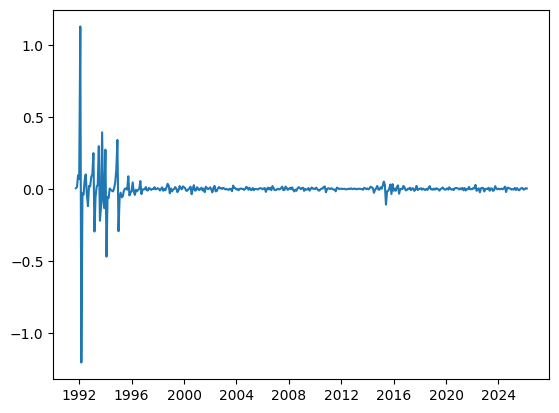

In [23]:
import matplotlib.pyplot as plt
plt.plot(main_data['infl_ukr_log'])

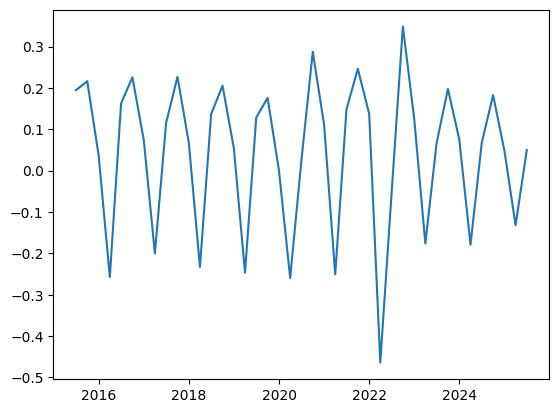

In [24]:
plt.plot(df_Ukraine_GDP_q['gdp_ua_log'])

In [57]:
main_data = main_data[221:]

In [61]:
path = r'C:\Users\User\Desktop\дані для диплому\mfvar_dataset.csv'
main_data.to_excel(path, index=True, encoding='utf-8')

In [62]:
path = r'C:\Users\User\Desktop\дані для диплому\mfvar_orig_dataset.csv'
main_data_orig.to_excel(path, index=True, encoding='utf-8')

In [64]:
main_data.tail(10)

,infl_ukr_log,gdp_ua_log
Показник,,
2025-05-31,0.005941,NaN
2025-06-30,-0.004948,0.049865
2025-07-31,-0.009970,NaN
2025-08-31,0.000000,NaN
2025-09-30,0.004998,NaN
2025-10-31,0.005964,NaN
2025-11-30,-0.004968,NaN
2025-12-31,-0.001994,NaN
2026-01-31,0.004978,NaN


In [28]:
season_dummy = pd.get_dummies(main_data.index.month, prefix='M',drop_first=True).astype(float)
season_dummy

,M_2,M_3,M_4,M_5,M_6,M_7,M_8,M_9,M_10,M_11,M_12
0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...
410,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
411,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
412,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
413,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [29]:
main_data

,infl_ukr_log,gdp_ua_log
Показник,,
1991-08-31,NaN,NaN
1991-09-30,0.004796,NaN
1991-10-31,0.013308,NaN
1991-11-30,0.095396,NaN
1991-12-31,0.067217,NaN
...,...,...
2025-10-31,0.005964,NaN
2025-11-30,-0.004968,NaN
2025-12-31,-0.001994,NaN


In [30]:
season_dummy.index = main_data.index
df_final = main_data.join(season_dummy)

In [31]:
df_final

,infl_ukr_log,gdp_ua_log,M_2,M_3,M_4,M_5,M_6,M_7,M_8,M_9,M_10,M_11,M_12
Показник,,,,,,,,,,,,,
1991-08-31,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
1991-09-30,0.004796,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1991-10-31,0.013308,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1991-11-30,0.095396,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1991-12-31,0.067217,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-10-31,0.005964,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2025-11-30,-0.004968,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2025-12-31,-0.001994,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [33]:
df_filtered = df_final.loc['2010':'2024']
df_filtered

,infl_ukr_log,gdp_ua_log,M_2,M_3,M_4,M_5,M_6,M_7,M_8,M_9,M_10,M_11,M_12
Показник,,,,,,,,,,,,,
2010-01-31,0.008880,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2010-02-28,0.000982,NaN,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2010-03-31,-0.009862,NaN,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2010-04-30,-0.011964,NaN,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2010-05-31,-0.003014,NaN,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-08-31,0.005982,NaN,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2024-09-30,0.008907,0.182948,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2024-10-31,0.002951,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [37]:
path = r'C:\Users\User\Desktop\дані для диплому\mfvar_dataset.xlsx'
df_filtered.to_excel(path, index=True)